# EDA

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('consumption_temp.csv')
df.head()

,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
1,2022-04-07 21:00:00,oslo,4.092830,1.0
2,2022-04-07 21:00:00,stavanger,2.057858,1.3
3,2022-04-07 21:00:00,tromsø,1.246582,-3.9
4,2022-04-07 21:00:00,trondheim,1.970098,-2.8


In [4]:
df['time'] = pd.to_datetime(df['time'])
print(df.info())
print(df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49494 entries, 0 to 49493
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         49494 non-null  datetime64[ns]
 1   location     49494 non-null  object        
 2   consumption  49494 non-null  float64       
 3   temperature  49494 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 1.5+ MB
None
time           0
location       0
consumption    0
temperature    0
dtype: int64

Number of duplicate rows: 0


In [ ]:
print(f"Number of unique locations: {df['location'].nunique()}")
print(f"Unique locations: {df['location'].unique()}")

df_bergen = df[df['location'] == 'bergen']
df_oslo = df[df['location'] == 'oslo']
df_stavanger = df[df['location'] == 'stavanger']
df_tromso = df[df['location'] == 'tromsø']
df_trondheim = df[df['location'] == 'trondheim']
df_helsingfors = df[df['location'] == 'helsingfors']

print(f"Bergen date range: {df_bergen['time'].min()} to {df_bergen['time'].max()}")
print(f"Oslo date range: {df_oslo['time'].min()} to {df_oslo['time'].max()}")
print(f"Stavanger date range: {df_stavanger['time'].min()} to {df_stavanger['time'].max()}")
print(f"Tromsø date range: {df_tromso['time'].min()} to {df_tromso['time'].max()}")
print(f"Trondheim date range: {df_trondheim['time'].min()} to {df_trondheim['time'].max()}")
print(f"Helsingfors date range: {df_helsingfors['time'].min()} to {df_helsingfors['time'].max()}")

print("(ex.) Bergen history length:", len(df_bergen))
df_bergen.head()

Number of unique locations: 6
Unique locations: ['bergen' 'oslo' 'stavanger' 'tromsø' 'trondheim' 'helsingfors']
Bergen date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Oslo date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Stavanger date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Tromsø date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Trondheim date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Helsingfors date range: 2022-07-14 21:00:00 to 2023-04-02 21:00:00
(ex.) Bergen history length: 8641


,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
5,2022-04-07 22:00:00,bergen,1.050327,0.0
10,2022-04-07 23:00:00,bergen,1.008794,-0.5
15,2022-04-08 00:00:00,bergen,0.984202,-1.1
20,2022-04-08 01:00:00,bergen,0.950335,-0.7


different date range in helsingfors df

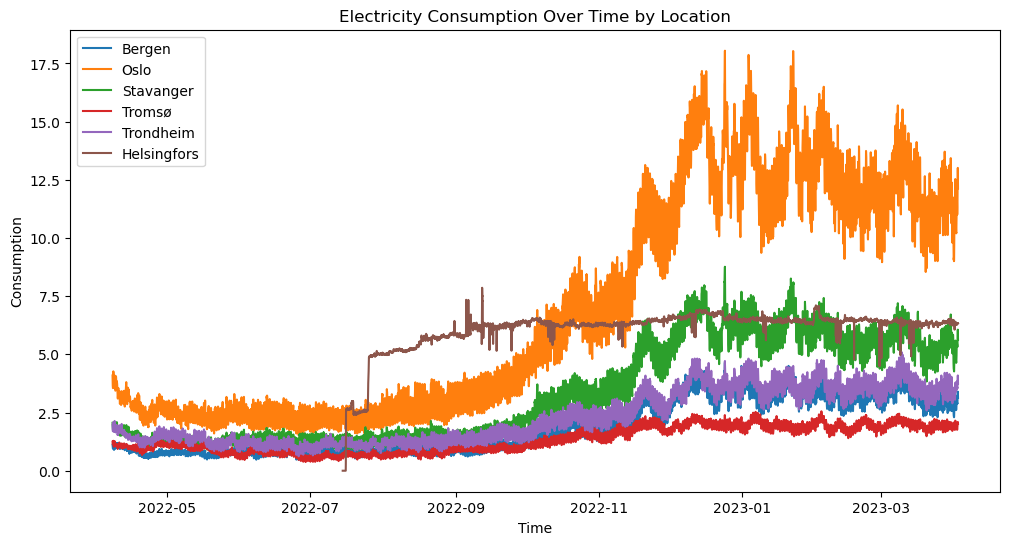

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_bergen['time'], df_bergen['consumption'], label='Bergen')
plt.plot(df_oslo['time'], df_oslo['consumption'], label='Oslo')
plt.plot(df_stavanger['time'], df_stavanger['consumption'], label='Stavanger')
plt.plot(df_tromso['time'], df_tromso['consumption'], label='Tromsø')
plt.plot(df_trondheim['time'], df_trondheim['consumption'], label='Trondheim')
plt.plot(df_helsingfors['time'], df_helsingfors['consumption'], label='Helsingfors')
plt.xlabel('Time')
plt.ylabel('Consumption')
plt.title('Electricity Consumption Over Time by Location')
plt.legend()
plt.show()

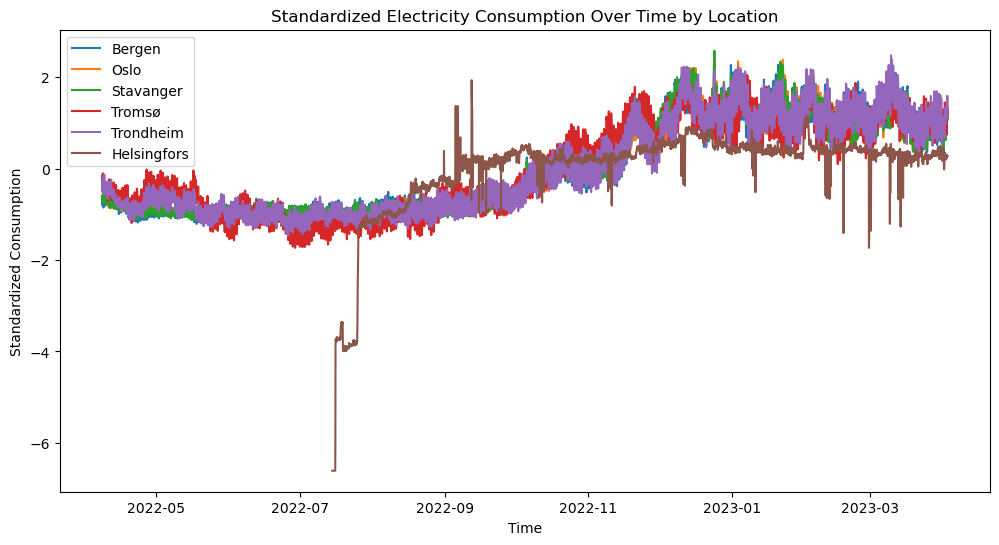

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_bergen['time'], (df_bergen['consumption'] - df_bergen['consumption'].mean()) / df_bergen['consumption'].std(), label='Bergen')
plt.plot(df_oslo['time'], (df_oslo['consumption'] - df_oslo['consumption'].mean()) / df_oslo['consumption'].std(), label='Oslo')
plt.plot(df_stavanger['time'], (df_stavanger['consumption'] - df_stavanger['consumption'].mean()) / df_stavanger['consumption'].std(), label='Stavanger')
plt.plot(df_tromso['time'], (df_tromso['consumption'] - df_tromso['consumption'].mean()) / df_tromso['consumption'].std(), label='Tromsø')
plt.plot(df_trondheim['time'], (df_trondheim['consumption'] - df_trondheim['consumption'].mean()) / df_trondheim['consumption'].std(), label='Trondheim')
plt.plot(df_helsingfors['time'], (df_helsingfors['consumption'] - df_helsingfors['consumption'].mean()) / df_helsingfors['consumption'].std(), label='Helsingfors')
plt.xlabel('Time')
plt.ylabel('Standardized Consumption')
plt.title('Standardized Electricity Consumption Over Time by Location')
plt.legend()
plt.show()

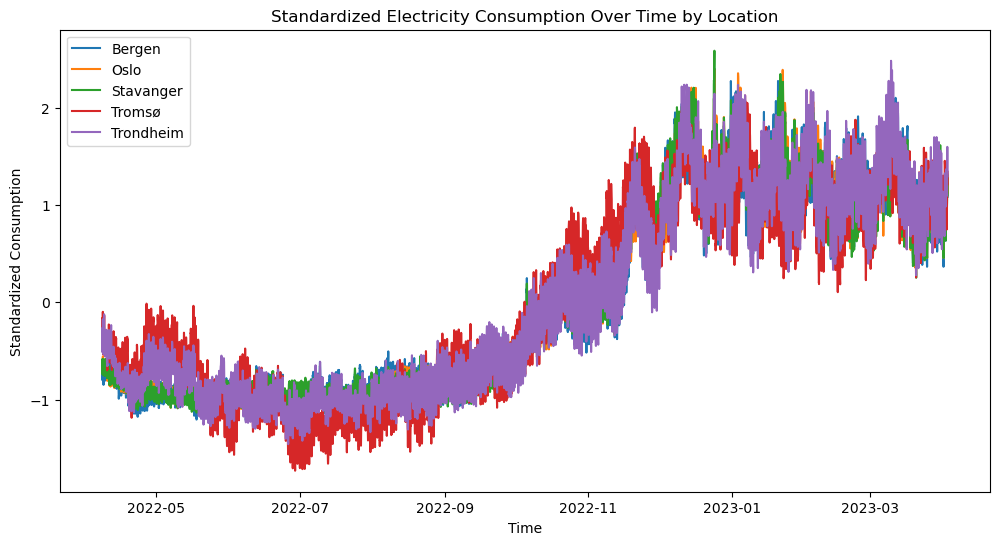

In [25]:
# plot all locations' standardized consumption over time in one plot
plt.figure(figsize=(12, 6))
plt.plot(df_bergen['time'], (df_bergen['consumption'] - df_bergen['consumption'].mean()) / df_bergen['consumption'].std(), label='Bergen')
plt.plot(df_oslo['time'], (df_oslo['consumption'] - df_oslo['consumption'].mean()) / df_oslo['consumption'].std(), label='Oslo')
plt.plot(df_stavanger['time'], (df_stavanger['consumption'] - df_stavanger['consumption'].mean()) / df_stavanger['consumption'].std(), label='Stavanger')
plt.plot(df_tromso['time'], (df_tromso['consumption'] - df_tromso['consumption'].mean()) / df_tromso['consumption'].std(), label='Tromsø')
plt.plot(df_trondheim['time'], (df_trondheim['consumption'] - df_trondheim['consumption'].mean()) / df_trondheim['consumption'].std(), label='Trondheim')
plt.xlabel('Time')
plt.ylabel('Standardized Consumption')
plt.title('Standardized Electricity Consumption Over Time by Location')
plt.legend()
plt.show()

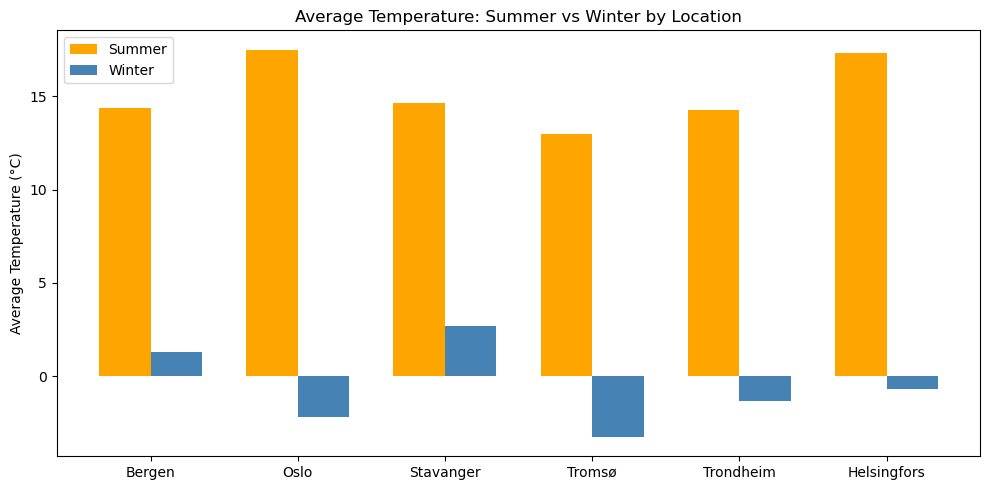

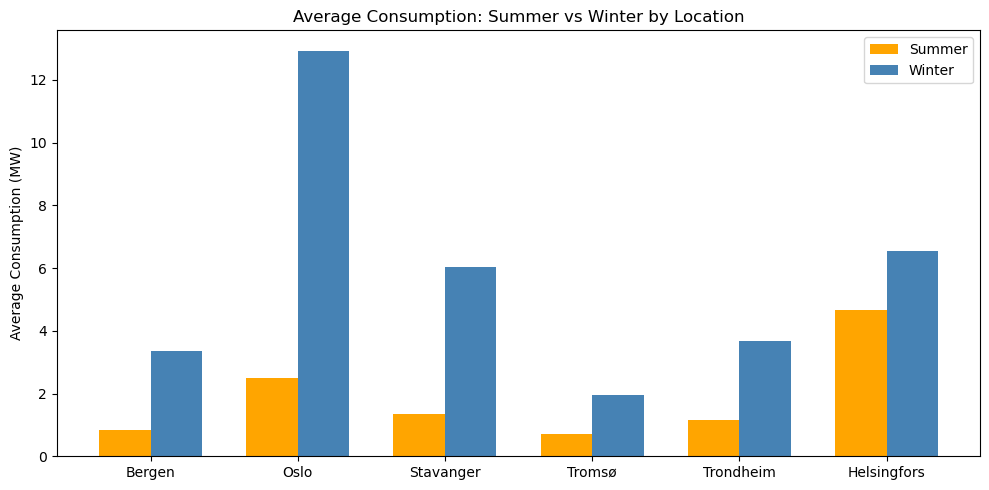

In [ ]:
df_bergen['month'] = df_bergen['time'].dt.month
df_oslo['month'] = df_oslo['time'].dt.month
df_stavanger['month'] = df_stavanger['time'].dt.month
df_tromso['month'] = df_tromso['time'].dt.month
df_trondheim['month'] = df_trondheim['time'].dt.month
df_helsingfors['month'] = df_helsingfors['time'].dt.month

summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

locations = {
    'Bergen': df_bergen, 'Oslo': df_oslo, 'Stavanger': df_stavanger,
    'Tromsø': df_tromso, 'Trondheim': df_trondheim, 'Helsingfors': df_helsingfors,
}

summer_temps, winter_temps = [], []
summer_cons, winter_cons = [], []

for name, d in locations.items():
    summer_temps.append(d[d['month'].isin(summer_months)]['temperature'].mean())
    winter_temps.append(d[d['month'].isin(winter_months)]['temperature'].mean())
    summer_cons.append(d[d['month'].isin(summer_months)]['consumption'].mean())
    winter_cons.append(d[d['month'].isin(winter_months)]['consumption'].mean())

names = list(locations.keys())
x = np.arange(len(names))
w = 0.35

# Plot 1: Temperature
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, summer_temps, w, label='Summer', color='orange')
ax.bar(x + w/2, winter_temps, w, label='Winter', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Average Temperature (°C)')
ax.set_title('Average Temperature: Summer vs Winter by Location')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: Consumption
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, summer_cons, w, label='Summer', color='orange')
ax.bar(x + w/2, winter_cons, w, label='Winter', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Average Consumption (MW)')
ax.set_title('Average Consumption: Summer vs Winter by Location')
ax.legend()
plt.tight_layout()
plt.show()

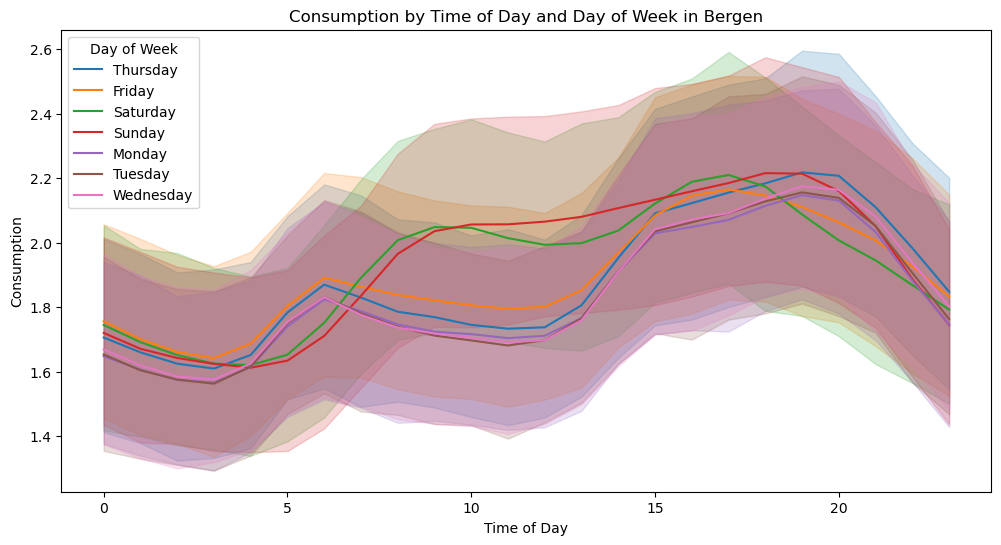

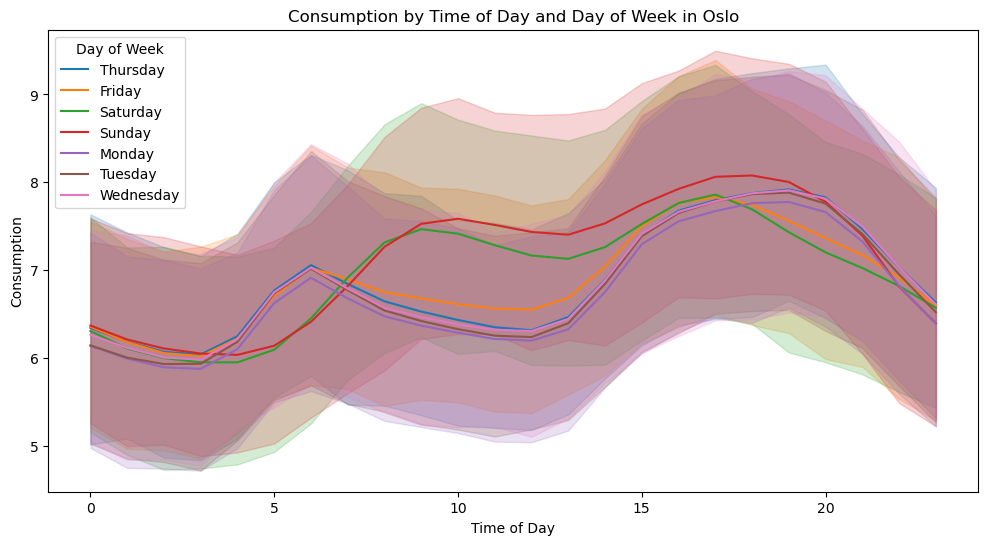

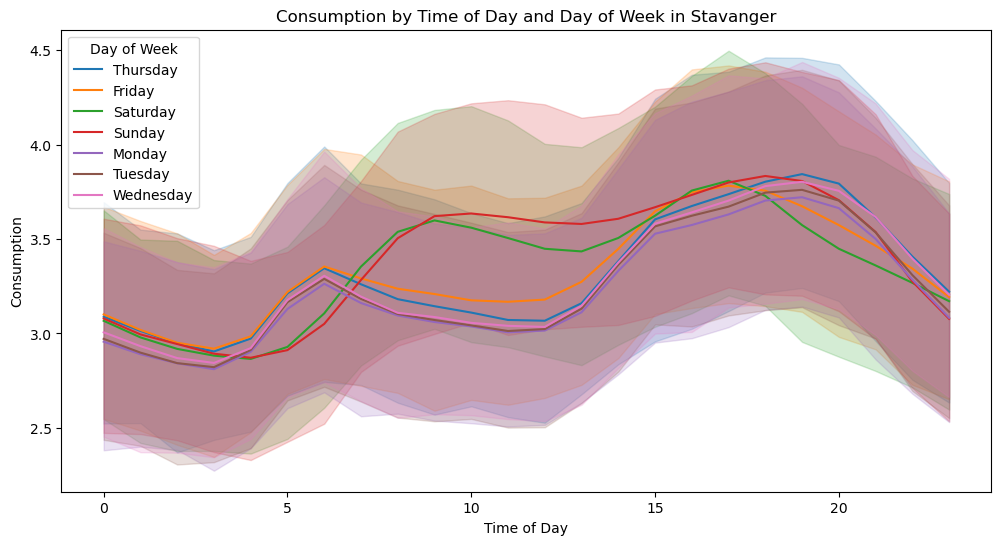

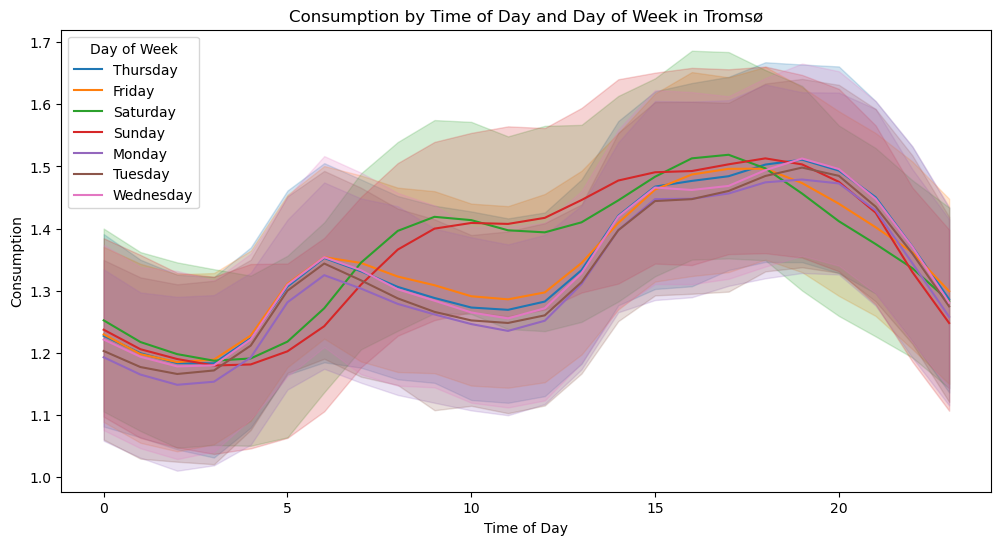

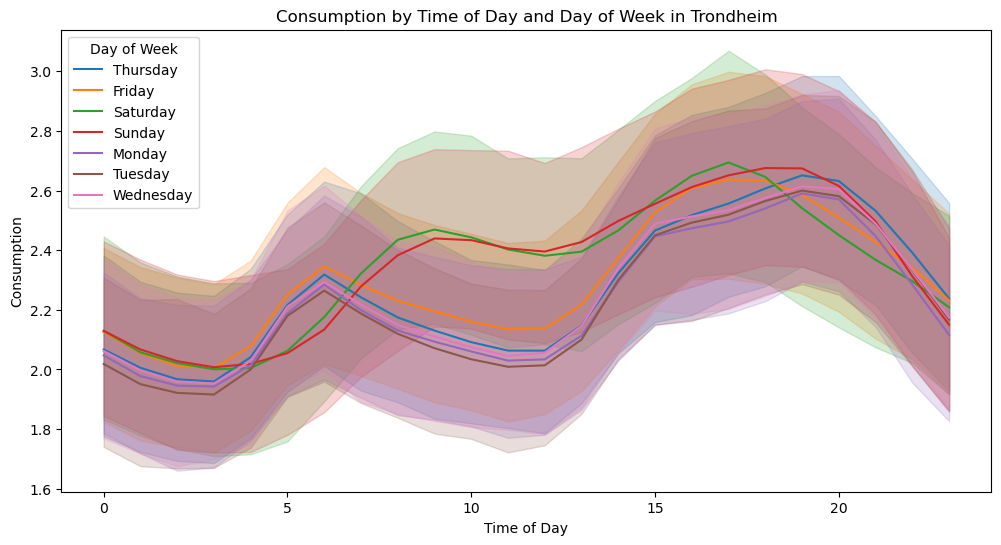

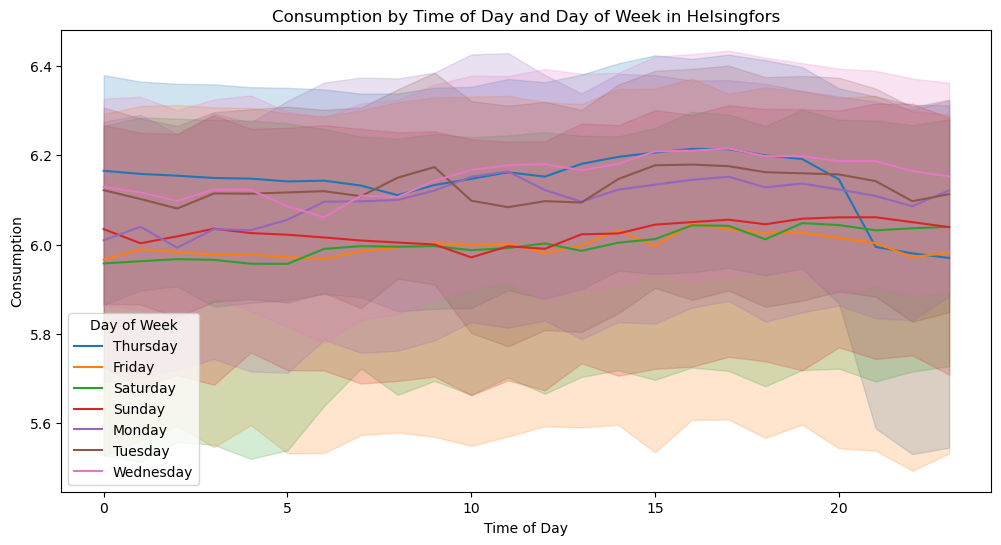

In [ ]:
for df in [df_bergen, df_oslo, df_stavanger, df_tromso, df_trondheim, df_helsingfors]:
    df['day_of_week'] = df['time'].dt.day_name()
    df['time_of_day'] = df['time'].dt.hour

for df, location in zip([df_bergen, df_oslo, df_stavanger, df_tromso, df_trondheim, df_helsingfors], 
                        ['Bergen', 'Oslo', 'Stavanger', 'Tromsø', 'Trondheim', 'Helsingfors']):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='time_of_day', y='consumption', hue='day_of_week', data=df)
    plt.title(f'Consumption by Time of Day and Day of Week in {location}')
    plt.xlabel('Time of Day')
    plt.ylabel('Consumption')
    plt.legend(title='Day of Week')
    plt.show()

small difference in pattern weekends midday

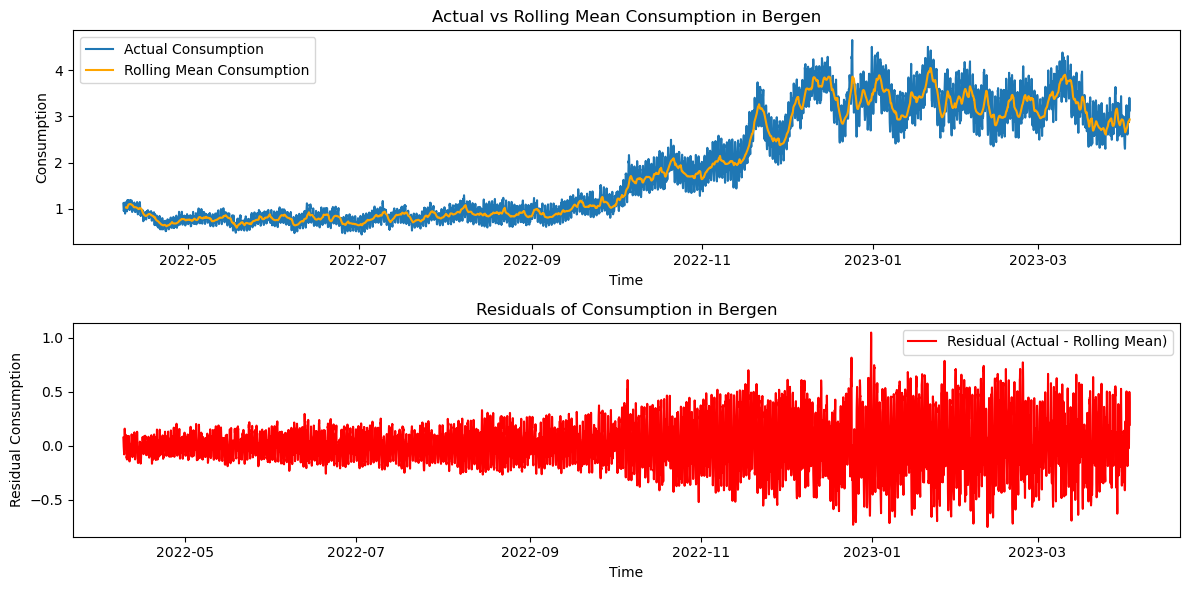

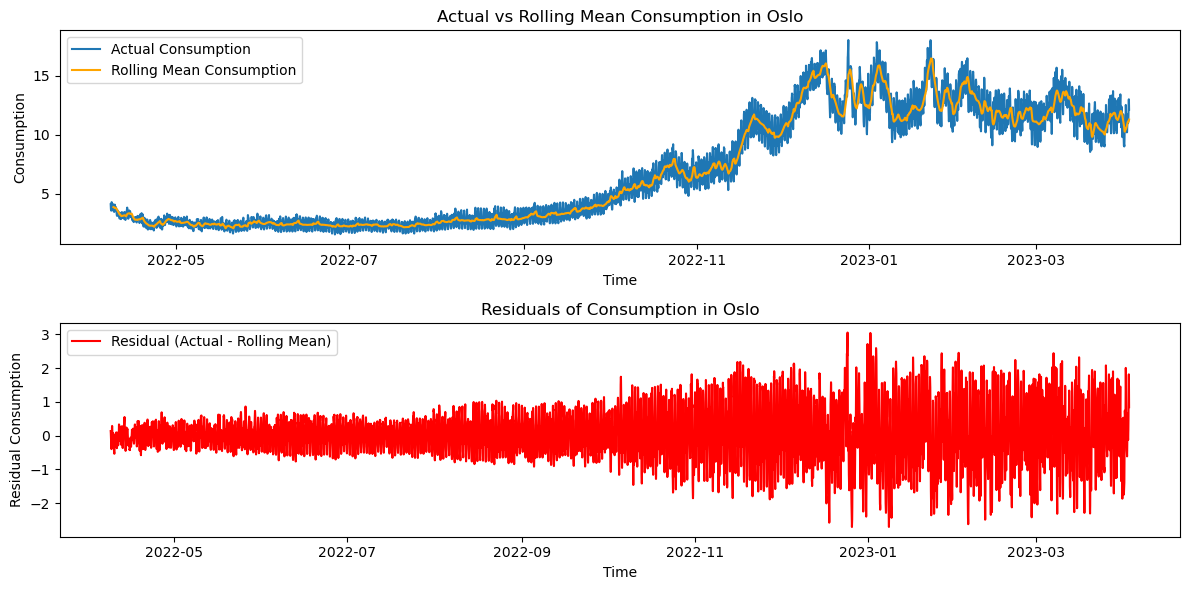

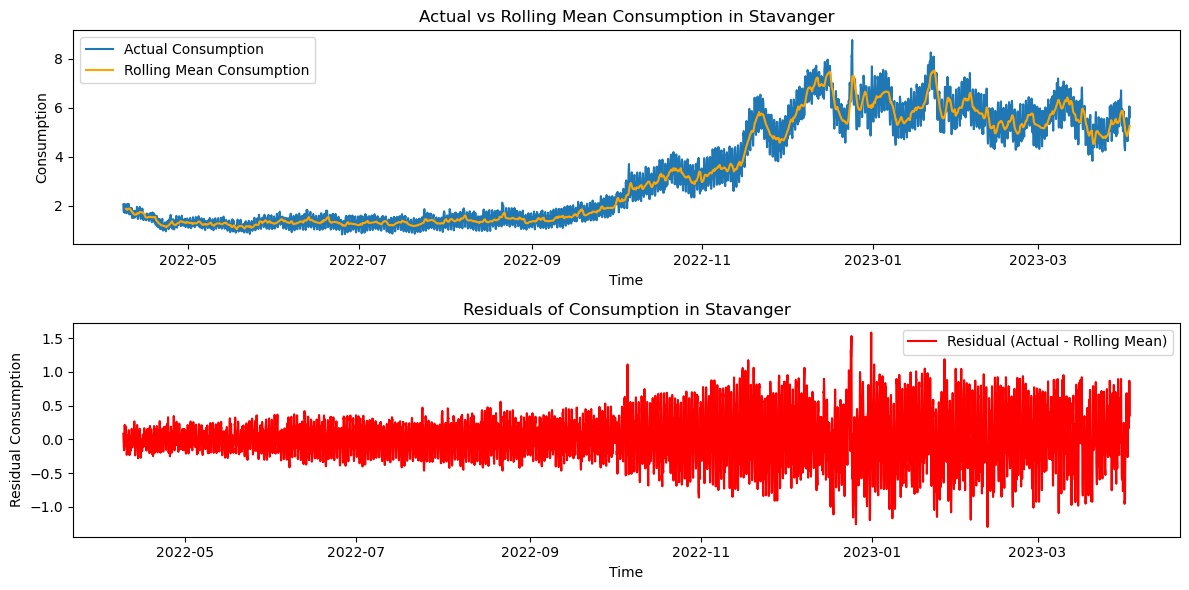

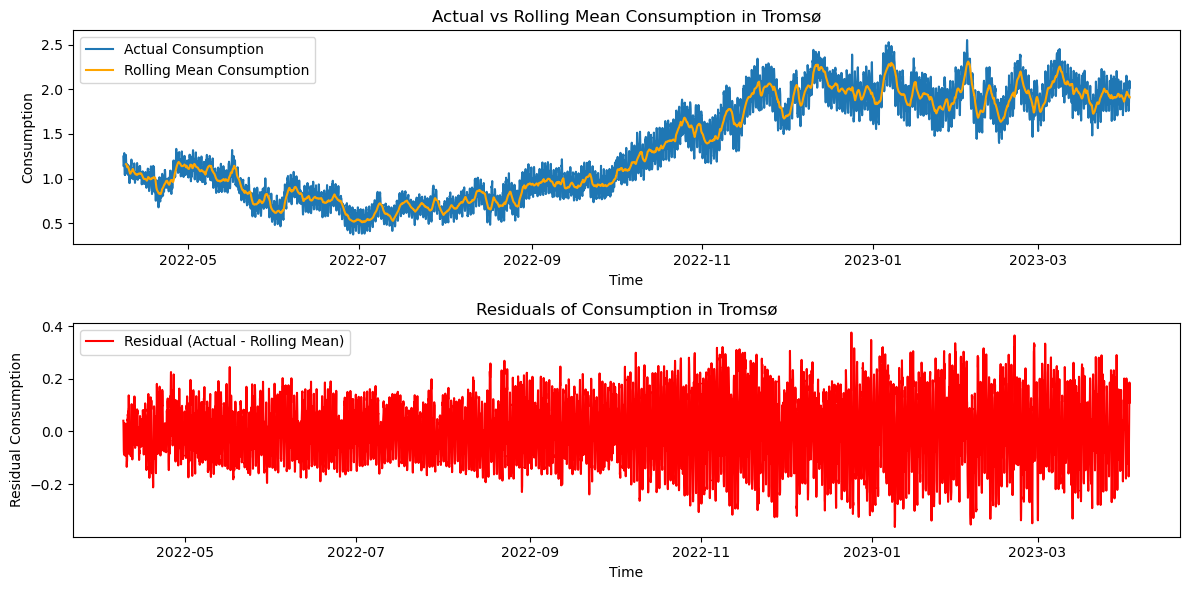

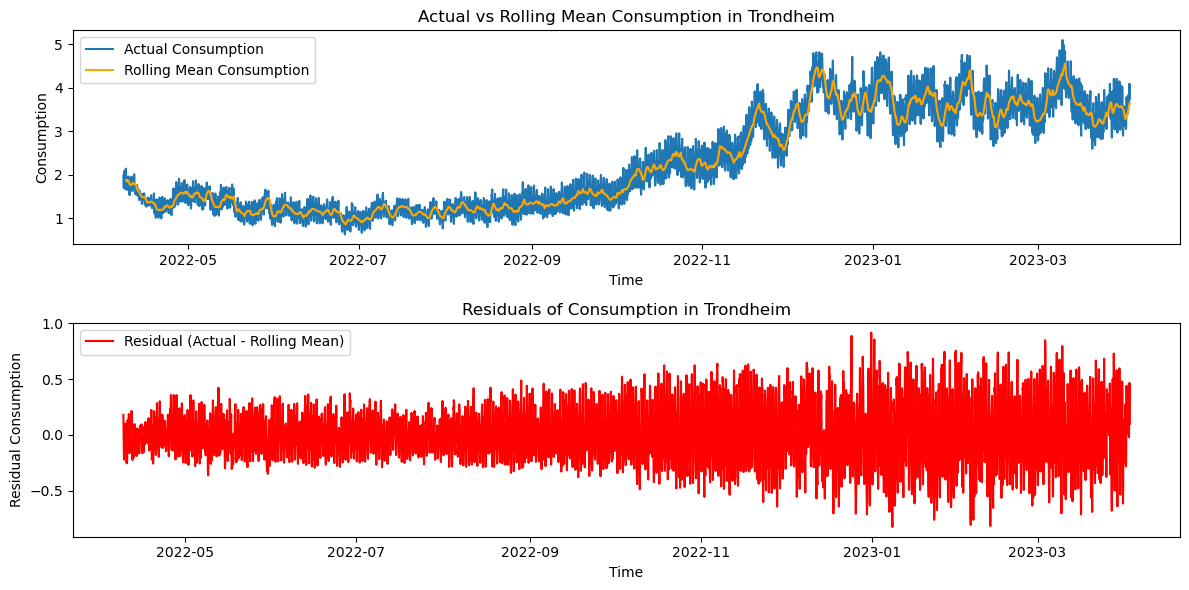

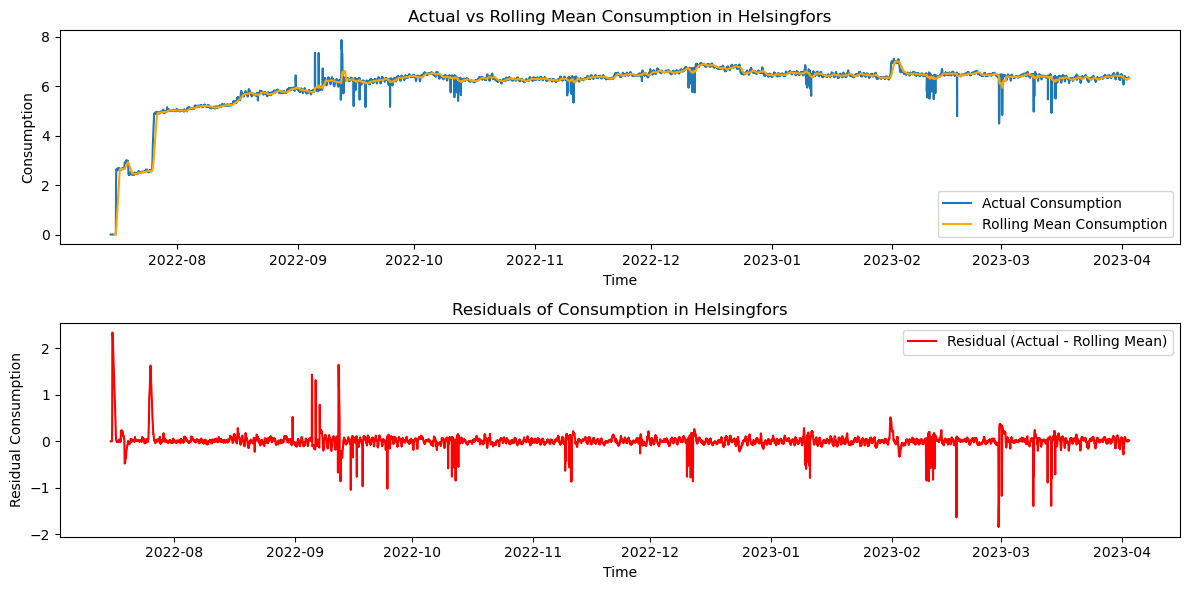

In [ ]:
for df, location in zip([df_bergen, df_oslo, df_stavanger, df_tromso, df_trondheim, df_helsingfors], 
                        ['Bergen', 'Oslo', 'Stavanger', 'Tromsø', 'Trondheim', 'Helsingfors']):
    df['rolling_mean'] = df['consumption'].rolling(window=24).mean()
    df['residual'] = df['consumption'] - df['rolling_mean']
    
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(df['time'], df['consumption'], label='Actual Consumption')
    plt.plot(df['time'], df['rolling_mean'], label='Rolling Mean Consumption', color='orange')
    plt.title(f'Actual vs Rolling Mean Consumption in {location}')
    plt.xlabel('Time')
    plt.ylabel('Consumption')
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(df['time'], df['residual'], label='Residual (Actual - Rolling Mean)', color='red')
    plt.title(f'Residuals of Consumption in {location}')
    plt.xlabel('Time')
    plt.ylabel('Residual Consumption')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
lags = [0, 24, 24*5, 24*7]
for df, location in zip([df_bergen, df_oslo, df_stavanger, df_tromso, df_trondheim, df_helsingfors], 
                        ['Bergen', 'Oslo', 'Stavanger', 'Tromsø', 'Trondheim', 'Helsingfors']):
    print(f"Lag analysis for {location}:")
    for lag in lags:
        if lag == 0:
            corr = df['consumption'].corr(df['consumption'])
            print(f"  Lag {lag} hours: Pearson's correlation = {corr:.4f}")
        else:
            corr = df['consumption'].corr(df['consumption'].shift(lag))
            print(f"  Lag {lag} hours: Pearson's correlation = {corr:.4f}")



Lag analysis for Bergen:
  Lag 0 hours: Pearson's correlation = 1.0000
  Lag 24 hours: Pearson's correlation = 0.9884
  Lag 120 hours: Pearson's correlation = 0.9588
  Lag 168 hours: Pearson's correlation = 0.9558
Lag analysis for Oslo:
  Lag 0 hours: Pearson's correlation = 1.0000
  Lag 24 hours: Pearson's correlation = 0.9898
  Lag 120 hours: Pearson's correlation = 0.9639
  Lag 168 hours: Pearson's correlation = 0.9593
Lag analysis for Stavanger:
  Lag 0 hours: Pearson's correlation = 1.0000
  Lag 24 hours: Pearson's correlation = 0.9899
  Lag 120 hours: Pearson's correlation = 0.9650
  Lag 168 hours: Pearson's correlation = 0.9603
Lag analysis for Tromsø:
  Lag 0 hours: Pearson's correlation = 1.0000
  Lag 24 hours: Pearson's correlation = 0.9867
  Lag 120 hours: Pearson's correlation = 0.9475
  Lag 168 hours: Pearson's correlation = 0.9481
Lag analysis for Trondheim:
  Lag 0 hours: Pearson's correlation = 1.0000
  Lag 24 hours: Pearson's correlation = 0.9854
  Lag 120 hours: Pears

Dataset constraint; consumption data is not available before 5 days passes

In [ ]:
for df, location in zip([df_bergen, df_oslo, df_stavanger, df_tromso, df_trondheim, df_helsingfors], 
                        ['Bergen', 'Oslo', 'Stavanger', 'Tromsø', 'Trondheim', 'Helsingfors']):
    corr = df['consumption'].corr(df['temperature'])
    print(f"Pearson's correlation between temperature and consumption in {location}: {corr:.4f}")



Pearson's correlation between temperature and consumption in Bergen: -0.7814
Pearson's correlation between temperature and consumption in Oslo: -0.8619
Pearson's correlation between temperature and consumption in Stavanger: -0.7817
Pearson's correlation between temperature and consumption in Tromsø: -0.8634
Pearson's correlation between temperature and consumption in Trondheim: -0.8378
Pearson's correlation between temperature and consumption in Helsingfors: -0.5679


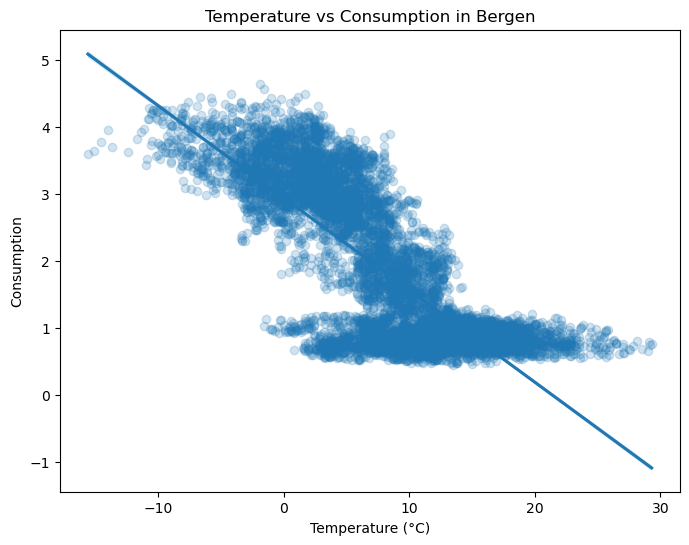

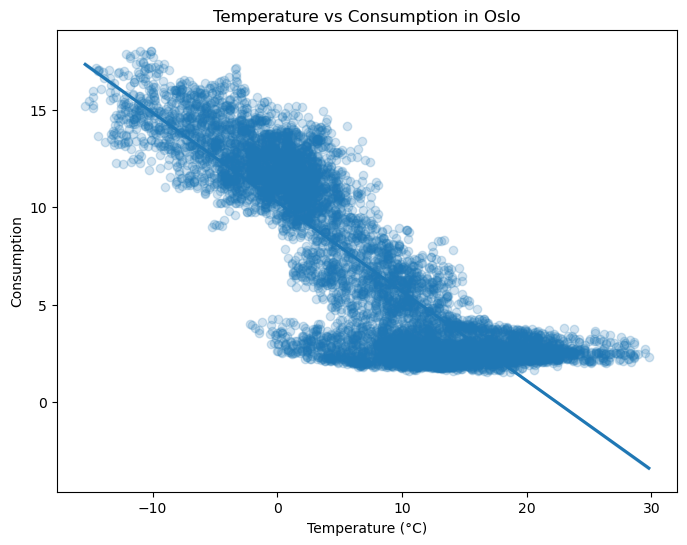

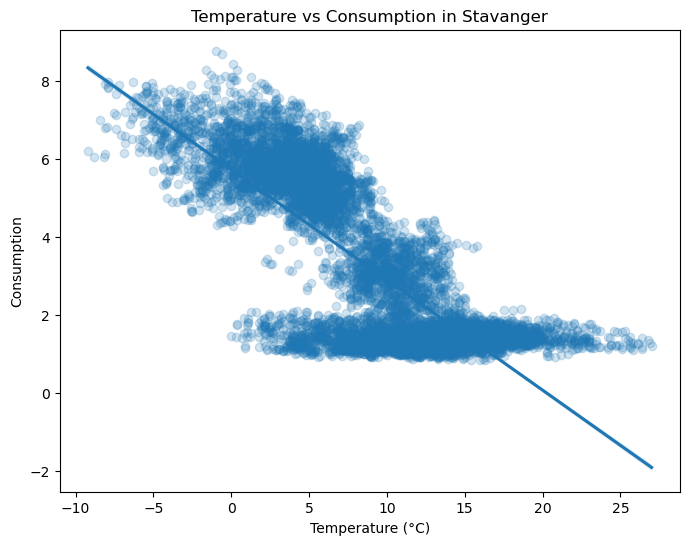

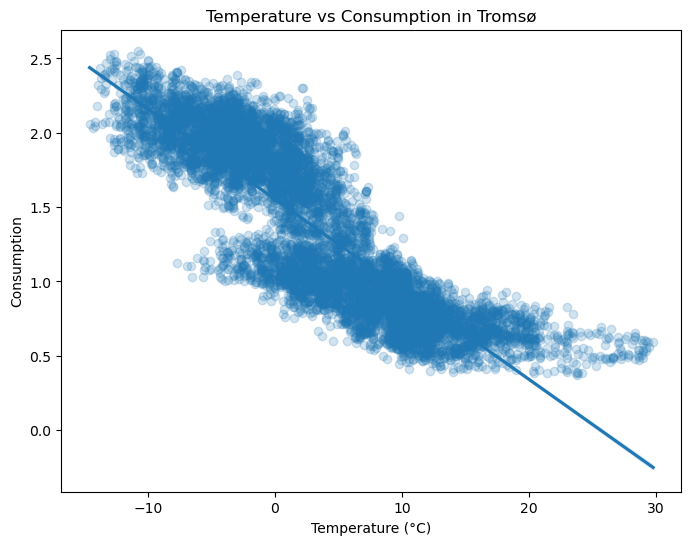

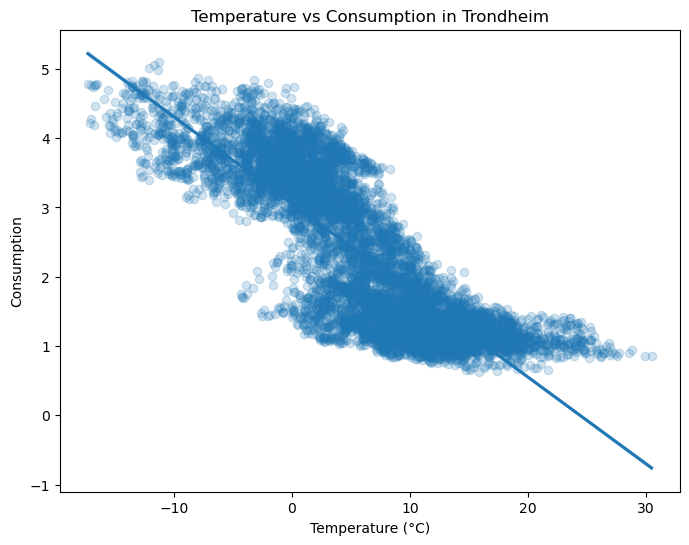

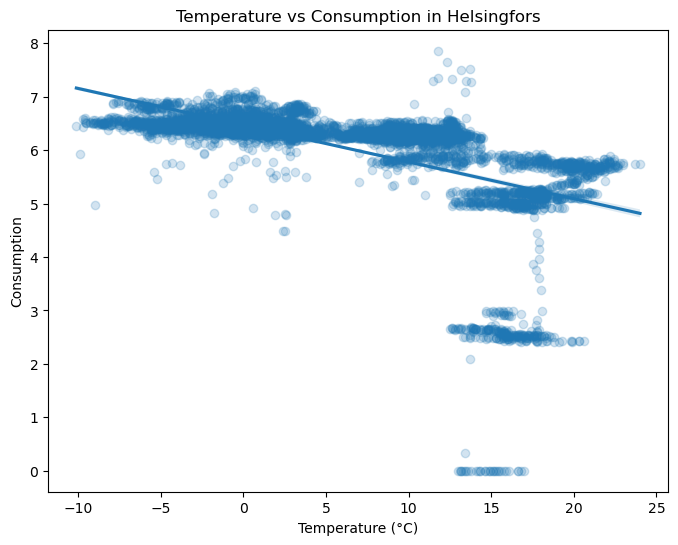

In [ ]:
for df, location in zip([df_bergen, df_oslo, df_stavanger, df_tromso, df_trondheim, df_helsingfors], 
                        ['Bergen', 'Oslo', 'Stavanger', 'Tromsø', 'Trondheim', 'Helsingfors']):
    plt.figure(figsize=(8, 6))
    sns.regplot(x='temperature', y='consumption', data=df, scatter_kws={'alpha':0.2})
    plt.title(f'Temperature vs Consumption in {location}')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Consumption')
    plt.show()


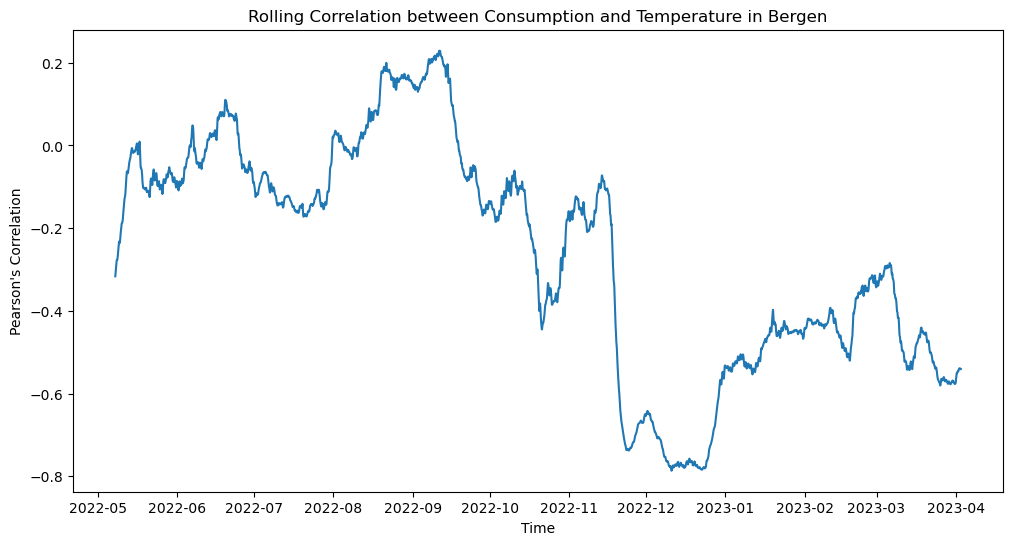

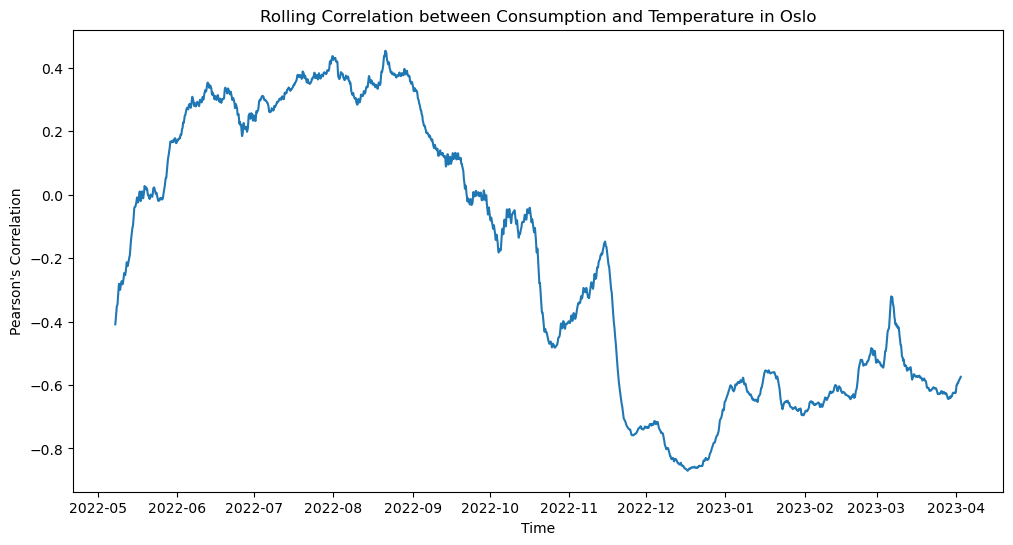

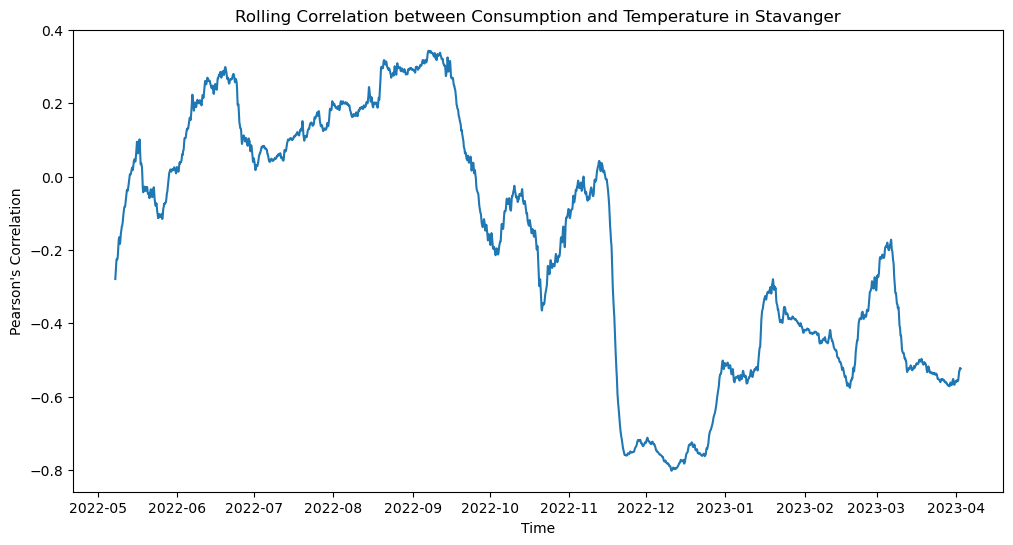

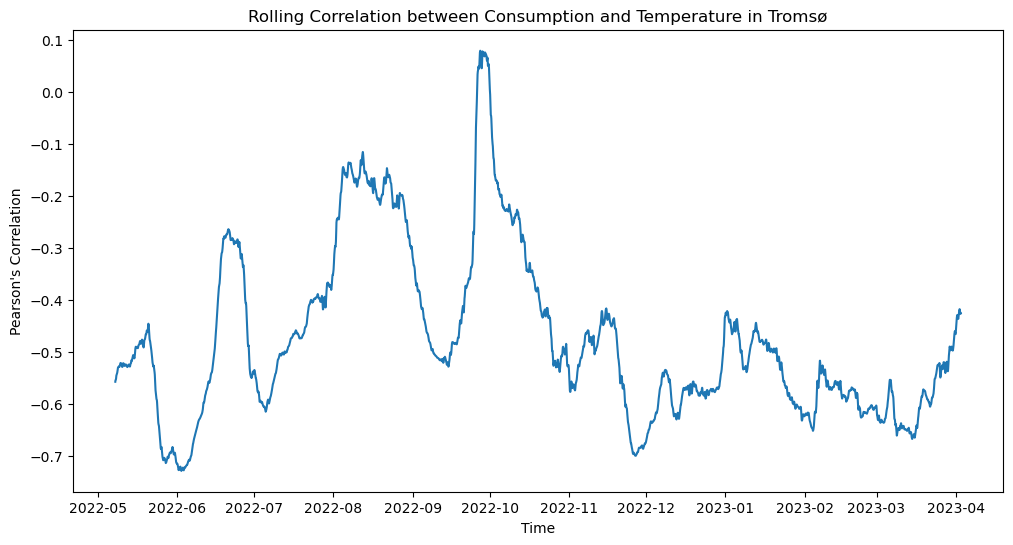

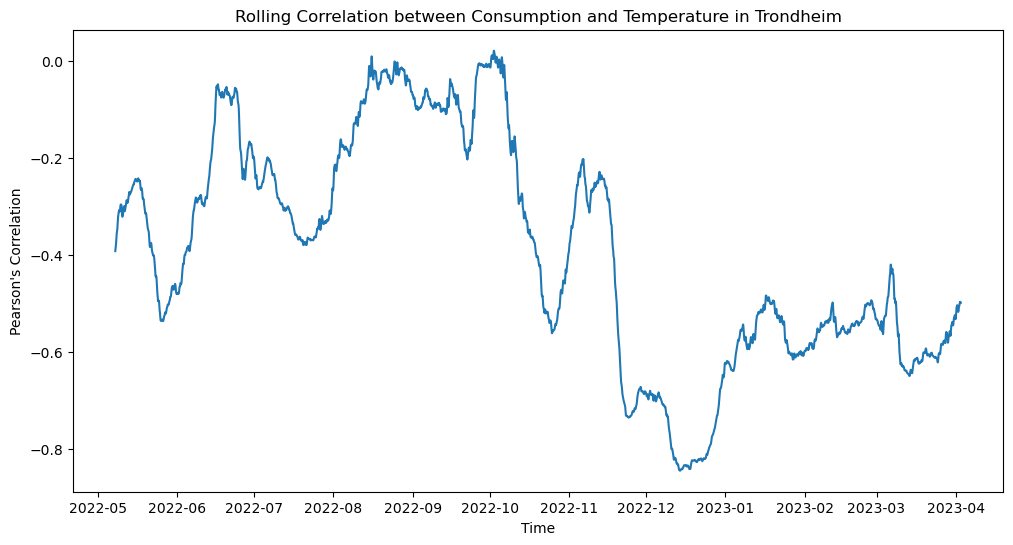

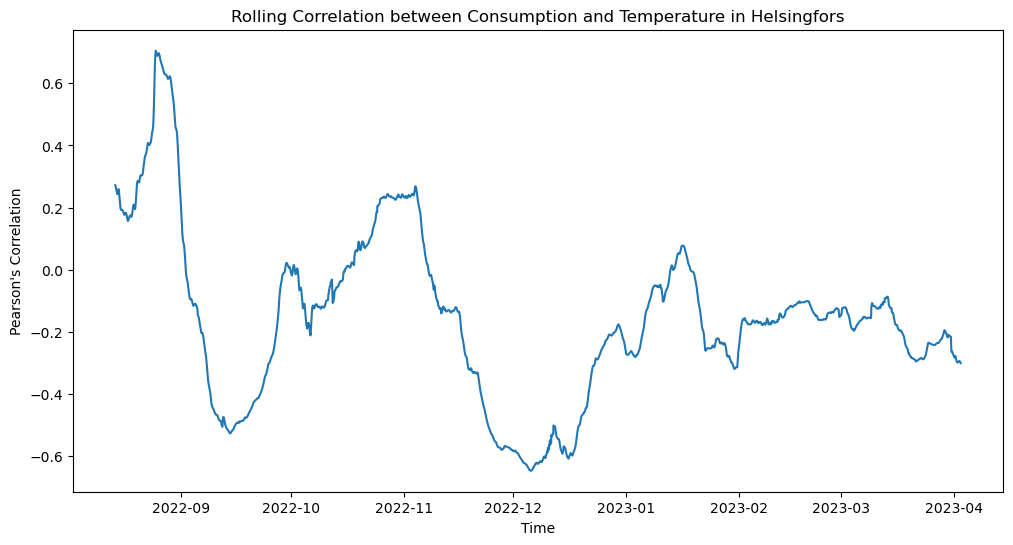

In [ ]:
window_size = 24 * 30
for df, location in zip([df_bergen, df_oslo, df_stavanger, df_tromso, df_trondheim, df_helsingfors], 
                        ['Bergen', 'Oslo', 'Stavanger', 'Tromsø', 'Trondheim', 'Helsingfors']):
    rolling_corr = df['consumption'].rolling(window=window_size).corr(df['temperature'])
    plt.figure(figsize=(12, 6))
    plt.plot(df['time'], rolling_corr)
    plt.title(f'Rolling Correlation between Consumption and Temperature in {location}')
    plt.xlabel('Time')
    plt.ylabel('Pearson\'s Correlation')
    plt.show()

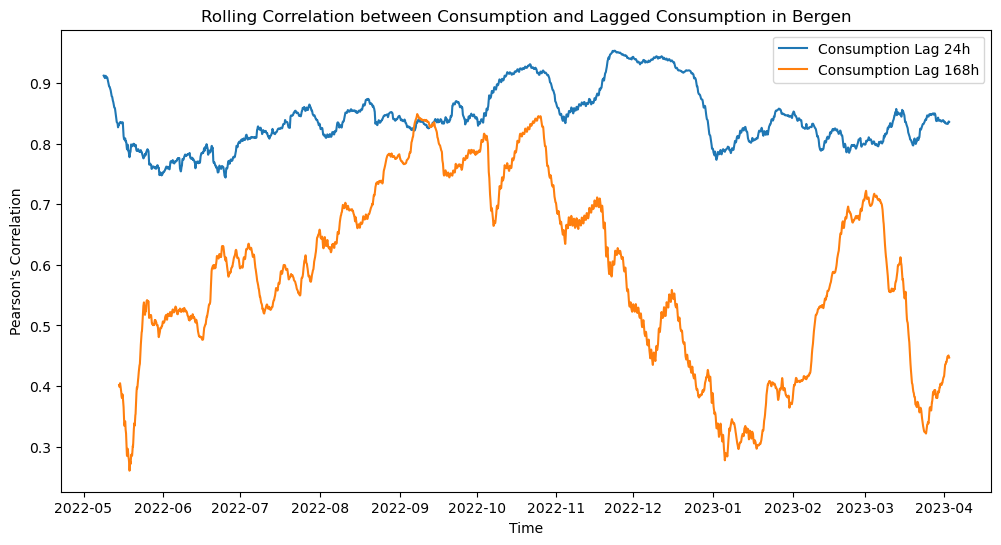

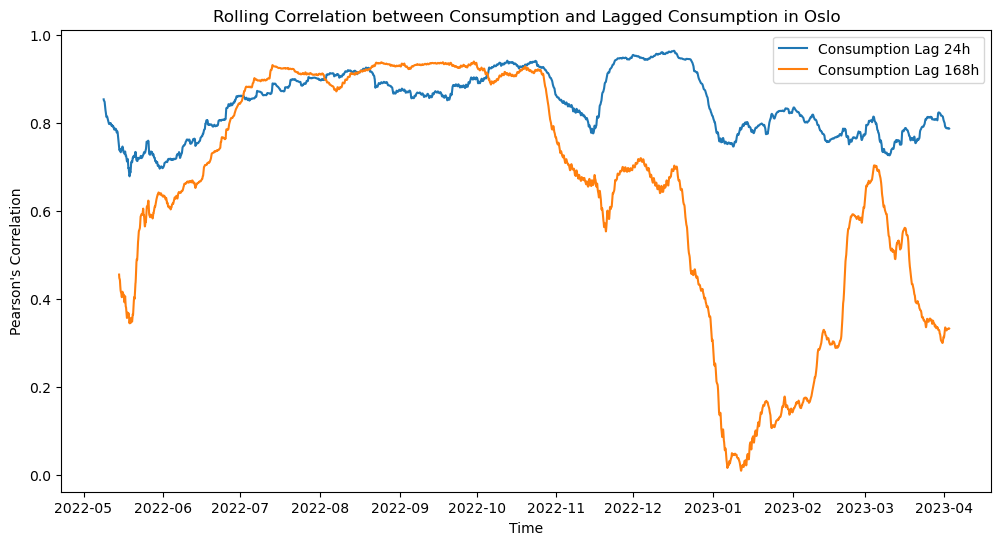

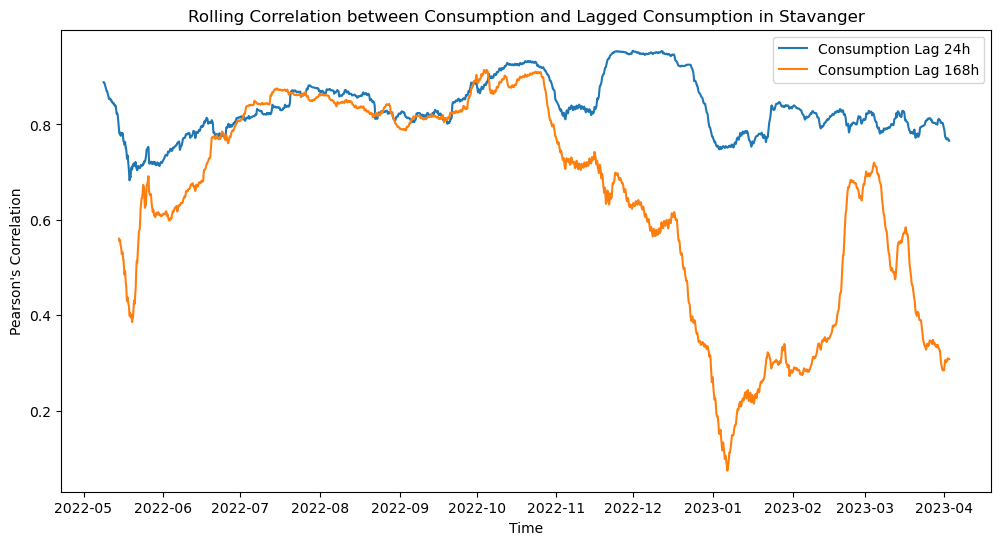

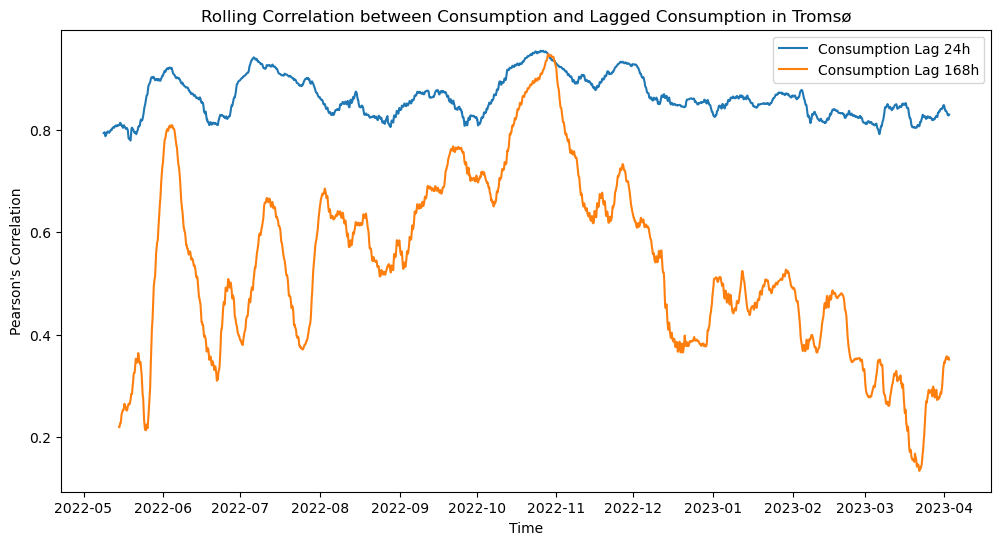

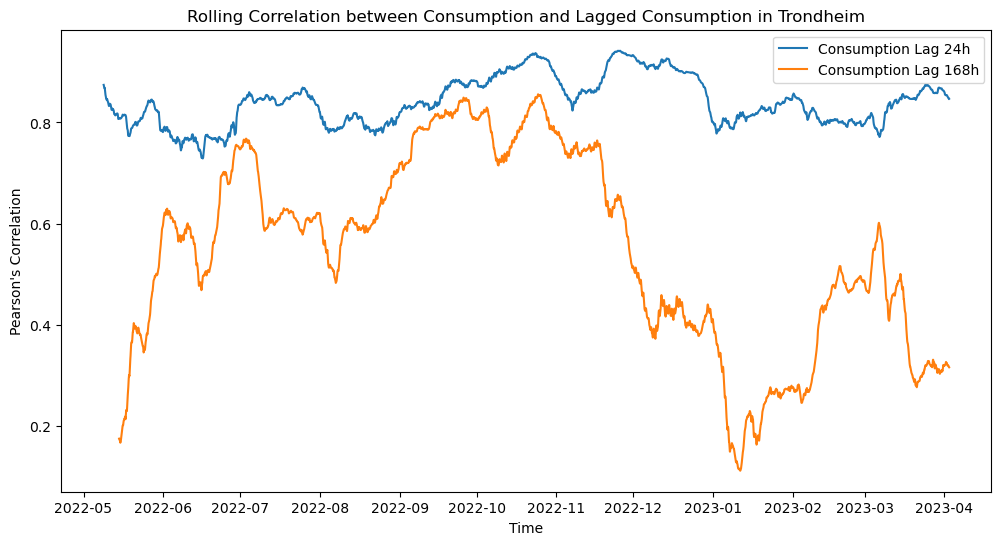

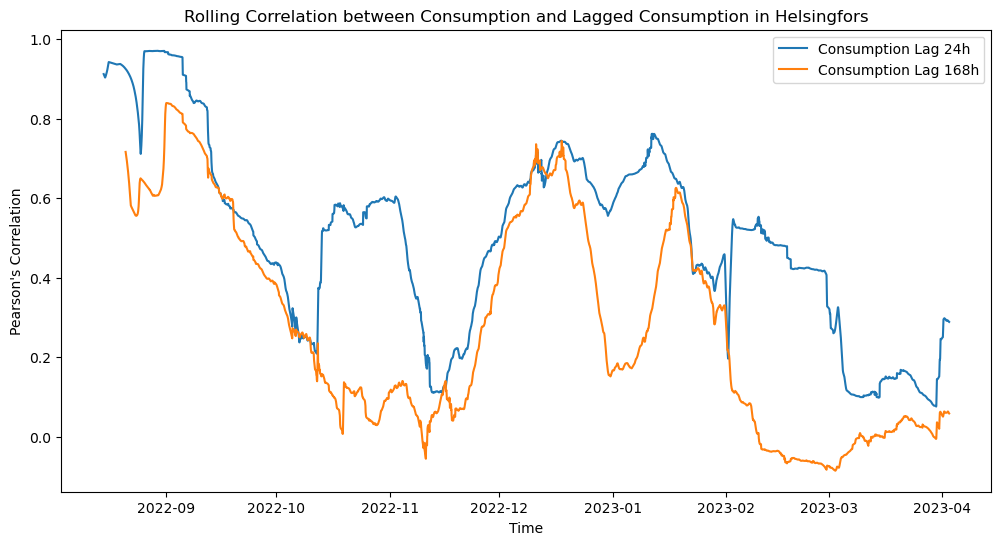

In [ ]:
window_size = 24 * 30

for df, location in zip([df_bergen, df_oslo, df_stavanger, df_tromso, df_trondheim, df_helsingfors], 
                        ['Bergen', 'Oslo', 'Stavanger', 'Tromsø', 'Trondheim', 'Helsingfors']):

    df['consumption_lag_24'] = df['consumption'].shift(24)
    df['consumption_lag_168'] = df['consumption'].shift(168)
    
    rolling_corr_24 = df['consumption'].rolling(window=window_size).corr(df['consumption_lag_24'])
    rolling_corr_168 = df['consumption'].rolling(window=window_size).corr(df['consumption_lag_168'])
    
    plt.figure(figsize=(12, 6))
    plt.plot(df['time'], rolling_corr_24, label='Consumption Lag 24h')
    plt.plot(df['time'], rolling_corr_168, label='Consumption Lag 168h')
    plt.title(f'Rolling Correlation between Consumption and Lagged Consumption in {location}')
    plt.xlabel('Time')
    plt.ylabel('Pearson\'s Correlation')
    plt.legend()
    plt.show()